In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
swaps_price_2000 = pd.read_csv("../ml output/2000-01-01/swap_paths.csv")
swaps_price_2000

,report_date,asset1,asset2,expiry_date,T_start,T_cur,date,value_start,value,is_expired,nominal
0,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.099206,2000-01-03,0.093100,NaN,False,1.0
1,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.095238,2000-01-04,0.093100,NaN,False,1.0
2,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.091270,2000-01-05,0.093100,NaN,False,1.0
3,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.087302,2000-01-06,0.093100,NaN,False,1.0
4,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.083333,2000-01-07,0.093100,0.116761,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...
204682,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.015873,2001-12-25,0.057463,0.185412,False,1.0
204683,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.011905,2001-12-26,0.057463,0.183282,False,1.0
204684,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.007937,2001-12-27,0.057463,0.181210,False,1.0
204685,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.003968,2001-12-28,0.057463,0.179101,False,1.0


In [3]:
amazon_adobe_swaps_2000 = swaps_price_2000[(swaps_price_2000['asset1'] == 'Amazon') &
                 (swaps_price_2000['asset2'] == 'Adobe')  &
                 (swaps_price_2000['T_start'] >= 2 )].copy()
amazon_adobe_swaps_2000

,report_date,asset1,asset2,expiry_date,T_start,T_cur,date,value_start,value,is_expired,nominal
676,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,2.063492,2000-01-03,0.22262,NaN,False,1.0
677,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,2.059524,2000-01-04,0.22262,NaN,False,1.0
678,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,2.055556,2000-01-05,0.22262,NaN,False,1.0
679,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,2.051587,2000-01-06,0.22262,NaN,False,1.0
680,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,2.047619,2000-01-07,0.22262,0.189577,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1192,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,0.015873,2001-12-25,0.22262,0.375615,False,1.0
1193,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,0.011905,2001-12-26,0.22262,0.373835,False,1.0
1194,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,0.007937,2001-12-27,0.22262,0.373689,False,1.0
1195,2000-01-01,Amazon,Adobe,2001-12-31,2.06746,0.003968,2001-12-28,0.22262,0.375323,False,1.0


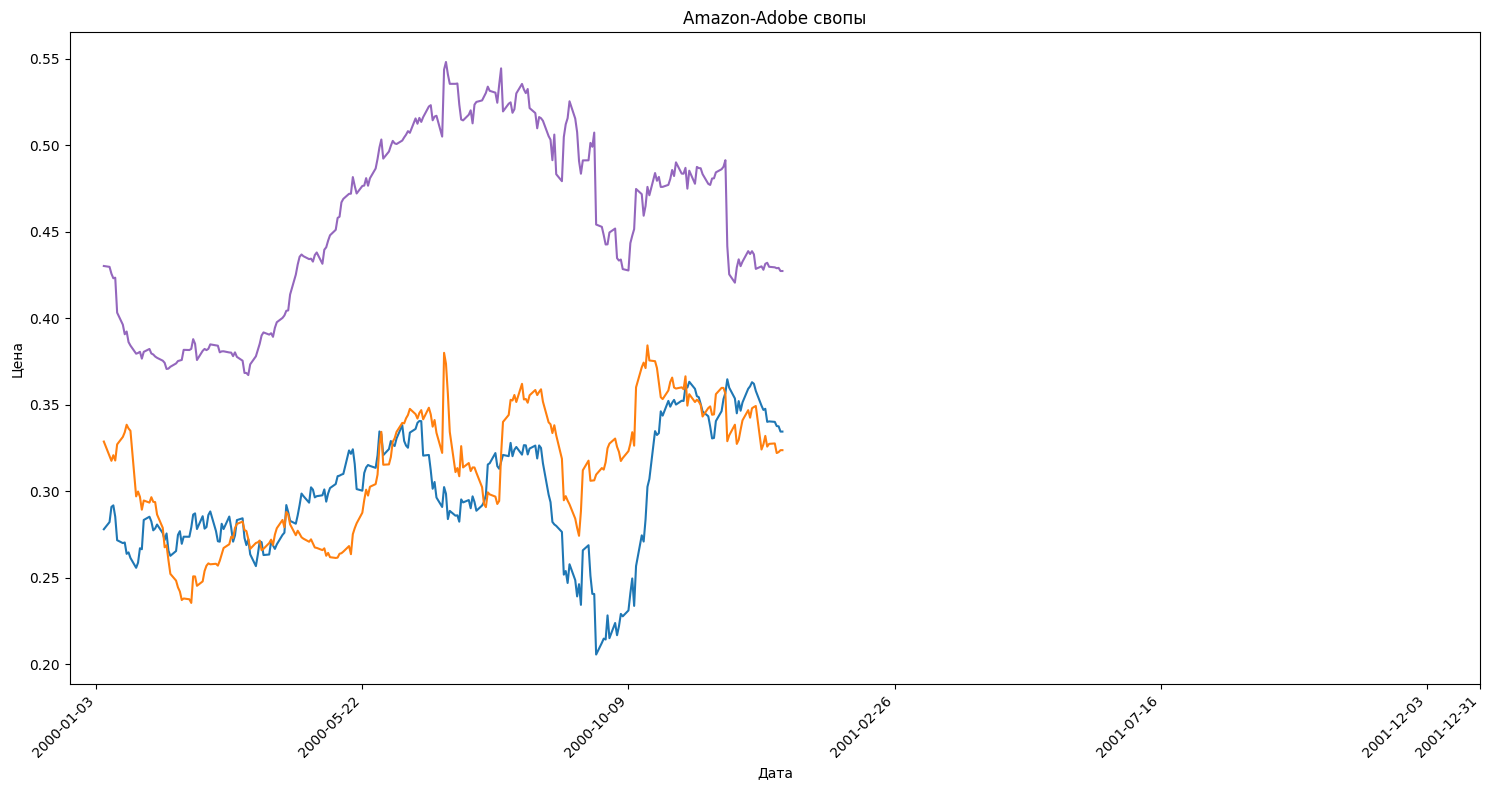

In [4]:
plt.figure(figsize=(15, 8))

for asset1 in swaps_price_2000['asset1'].unique():
    for asset2 in swaps_price_2000['asset2'].unique(): 

        if asset1 not in ['Intel', 'Oracle', 'Qualcomm', 'Amazon', 'Check Point Software'] or asset2 not in ['Intel', 'Oracle', 'Qualcomm', 'Amazon', 'Check Point Software']:
            continue
        swaps_price = swaps_price_2000[(swaps_price_2000['asset1'] == asset1) &
                        (swaps_price_2000['asset2'] == asset2)  &
                        (swaps_price_2000['T_start'] >= 1 ) & (swaps_price_2000['T_start'] <= 2)].copy()

        dates = pd.to_datetime(swaps_price['date'])
        plt.plot(dates, swaps_price['value'], label=f'{asset1}-{asset2}')

step = 100
dates = swaps_price_2000['date'].unique() 
n = len(dates)
tick_idx = list(range(0, n, step))
if n > 0 and tick_idx[-1] != n - 1:
    tick_idx.append(n - 1)
plt.xticks(dates[tick_idx], rotation=45, ha='right')

plt.title('Amazon-Adobe свопы')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.tight_layout()
plt.show()

In [5]:
plt.rcParams.update({
    "savefig.transparent": True,
    "figure.facecolor": "none",
    "axes.facecolor":   "none",
    "axes.edgecolor":   "#888",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#888",
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "xtick.major.size": 0, "xtick.minor.size": 0,
    "ytick.major.size": 0, "ytick.minor.size": 0,
    "xtick.color": "#444",
    "ytick.color": "#444",
})

In [6]:
def load_simulation_data(folder: str | Path):
    """Загружает датасеты и подготавливает unit-P&L свопов.

    Стратегия начинается с первой даты, на которой у всех свопов уже есть
    валидная котировка `value` (до этого `value` бывает NaN из-за warm-up
    модели). Эта котировка считается ценой покупки свопа (anchor),
    `value_start` из CSV игнорируется. Тогда unit_pnl = value[t] − anchor,
    в момент входа = 0, без скачка на первой марк-ту-маркет переоценке.
    """
    folder = Path(folder)
    with open(folder / "config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    prices = pd.read_csv(folder / "prices_close.csv", parse_dates=["date"]).set_index("date")
    report_date = pd.Timestamp(config["report_date"])
    prices = prices[prices.index >= report_date].sort_index()
    prices = prices[config["assets"]]

    swap_paths = pd.read_csv(folder / "swap_paths.csv", parse_dates=["date", "expiry_date"])

    T_array = list(config["T_array"])

    def nearest_T(t: float) -> float:
        return min(T_array, key=lambda x: abs(x - t))

    sp = swap_paths.copy()
    sp["T_bucket"] = sp["T_start"].apply(nearest_T)
    sp["pair"] = sp["asset1"] + "|" + sp["asset2"]
    sp = sp.sort_values(["pair", "T_bucket", "date"])

    # ffill — на случай дат после экспирации; bfill — для leading NaN до первой котировки
    sp["value_ff"] = sp.groupby(["pair", "T_bucket"])["value"].ffill()
    sp["value_ff"] = sp.groupby(["pair", "T_bucket"])["value_ff"].bfill()
    # anchor = первая валидная котировка = цена покупки свопа
    sp["anchor"] = sp.groupby(["pair", "T_bucket"])["value_ff"].transform("first")
    sp["unit_pnl"] = sp["value_ff"] - sp["anchor"]

    # стартовая дата стратегии = когда у ВСЕХ свопов уже есть валидная котировка
    valid = swap_paths.dropna(subset=["value"]).copy()
    valid["T_bucket"] = valid["T_start"].apply(nearest_T)
    valid["pair"] = valid["asset1"] + "|" + valid["asset2"]
    first_valid_dates = valid.groupby(["pair", "T_bucket"])["date"].min()
    strategy_start = pd.Timestamp(first_valid_dates.max())
    prices = prices[prices.index >= strategy_start]

    swap_pnl_by_T: dict[float, pd.DataFrame] = {}
    for T_bucket, group in sp.groupby("T_bucket"):
        piv = group.pivot_table(index="date", columns="pair", values="unit_pnl", aggfunc="last")
        piv = piv.reindex(prices.index).ffill().fillna(0.0)
        swap_pnl_by_T[float(T_bucket)] = piv

    return config, prices, swap_pnl_by_T


def simulate_portfolio(
    config: dict,
    prices: pd.DataFrame,
    swap_pnl_by_T: dict[float, pd.DataFrame],
    weights: dict[str, float],
    nominals_T: dict[float, float],
    end_date,
    rf_rate: float = 0.04,
):
    """Моделирует портфель и возвращает его динамику.

    cash[t]   — баланс наличности (в момент 0 = -cost; начисляется/уплачивается rf),
    index[t]  — рыночная стоимость купленного индекса (sum_i w_i * p_i_t / p_i_0),
    swap[t]   — суммарный M2M-P&L всех активных свопов,
    total[t]  — cash + index + swap. В t=0 равно 0 по построению.
    """
    active = {a: float(w) for a, w in weights.items() if w > 0 and a in prices.columns}
    if not active:
        return None

    sub = prices[list(active.keys())]
    sub = sub[sub.index <= pd.Timestamp(end_date)].dropna(how="any")
    if len(sub) < 2:
        return None

    p0 = sub.iloc[0]
    norm = sub / p0
    w = pd.Series(active)
    invested = float(w.sum())

    index_value = (norm * w).sum(axis=1)

    dates = sub.index
    days = (dates - dates[0]).days.values.astype(float)
    dt = np.diff(days, prepend=days[0]) / 365.0
    cash = np.empty(len(dates))
    cash[0] = -invested
    for i in range(1, len(dates)):
        cash[i] = cash[i - 1] * (1.0 + rf_rate * dt[i])
    cash = pd.Series(cash, index=dates)

    swap_pnl = pd.Series(0.0, index=dates)
    active_set = set(active.keys())
    end_ts = pd.Timestamp(end_date)
    for T_bucket, piv in swap_pnl_by_T.items():
        nominal = float(nominals_T.get(T_bucket, 0.0))
        if nominal <= 0:
            continue
        cols = [c for c in piv.columns
                if c.split("|", 1)[0] in active_set and c.split("|", 1)[1] in active_set]
        if not cols:
            continue
        contrib = piv.loc[piv.index <= end_ts, cols].sum(axis=1) * nominal
        swap_pnl = swap_pnl.add(contrib.reindex(dates).fillna(0.0), fill_value=0.0)

    total = cash + index_value + swap_pnl

    return {
        "dates": dates,
        "cash": cash,
        "index": index_value,
        "swap_pnl": swap_pnl,
        "total_pnl": total,
        "invested": invested,
    }


def compute_ratios(total_pnl: pd.Series, invested: float,
                   rf_rate: float = 0.04, periods_per_year: int = 252):
    """Sharpe и Martin (UPI) на $-приращениях total_pnl с поправкой на rf.

    Используем $-изменения (а не pct_change equity), чтобы корректно работать
    при больших номиналах свопов, когда equity-кривая может уйти ниже нуля.

    rf-поправка вычитается из ежедневного P&L как «бенчмарк инвестирования
    всего invested под rf»:
        excess_d = pnl_d − invested * rf_rate / periods_per_year
    Это нужно, чтобы сравнение портфелей с разной долей cash было честным
    (иначе у cash-heavy портфеля проявляется фантомный бонус от cash-ножки).

    Sharpe = mean(excess_d) / std(pnl_d) * sqrt(252)
    Martin = annualized_excess_return_pct / ulcer_index
            где ulcer_index = sqrt(mean(drawdown_pct^2))
    """
    pnl_d = total_pnl.diff().dropna()
    if len(pnl_d) < 2 or pnl_d.std() == 0:
        return float("nan"), float("nan")

    daily_rf = invested * rf_rate / periods_per_year
    excess_d = pnl_d - daily_rf

    sharpe = excess_d.mean() / pnl_d.std() * np.sqrt(periods_per_year)

    equity = invested + total_pnl
    running_max = equity.cummax().clip(lower=invested)
    drawdown_pct = (equity / running_max - 1.0) * 100.0
    ulcer = float(np.sqrt((drawdown_pct ** 2).mean()))
    if ulcer == 0:
        return float(sharpe), float("nan")
    ann_excess_pct = float(excess_d.mean()) * periods_per_year / invested * 100.0
    martin = ann_excess_pct / ulcer
    return float(sharpe), float(martin)

In [7]:
DATA_FOLDER = "../ml output/2000-01-01"
_config, _prices, _swap_pnl_by_T = load_simulation_data(DATA_FOLDER)
print(f"Активов: {len(_config['assets'])} | T-бакетов: {len(_config['T_array'])} | "
      f"торговых дат: {len(_prices)} | окно: {_prices.index[0].date()} … {_prices.index[-1].date()}")

Активов: 19 | T-бакетов: 6 | торговых дат: 748 | окно: 2000-01-07 … 2002-12-31


In [8]:
def build_portfolio_dashboard(config, prices, swap_pnl_by_T):
    assets   = list(config["assets"])
    T_array  = [float(t) for t in config["T_array"]]
    expiry   = dict(zip(T_array, config.get("swap_expiry_dates", [""] * len(T_array))))

    style_lbl = {"description_width": "170px"}
    style_T   = {"description_width": "120px"}

    weight_w = {
        a: widgets.FloatSlider(
            value=float(config["weights"].get(a, 1.0 / len(assets))),
            min=0.0, max=1.0, step=0.01,
            description=a, style=style_lbl,
            continuous_update=False, readout_format=".2f",
            layout=widgets.Layout(width="430px"),
        )
        for a in assets
    }

    nominal_w = {
        T: widgets.FloatSlider(
            value=0.0, min=0.0, max=10.0, step=0.05,
            description=f"T={T:g}  ({expiry.get(T, '')})",
            style=style_T, continuous_update=False, readout_format=".2f",
            layout=widgets.Layout(width="430px"),
        )
        for T in T_array
    }

    rf_w = widgets.FloatSlider(
        value=0.04, min=0.0, max=0.15, step=0.0025,
        description="rf (год.)", style=style_T,
        continuous_update=False, readout_format=".3f",
        layout=widgets.Layout(width="430px"),
    )

    avail_dates = list(prices.index)
    date_options = [d.strftime("%Y-%m-%d") for d in avail_dates[1:]]
    date_w = widgets.SelectionSlider(
        options=date_options,
        value=date_options[-1],
        description="Конец периода",
        style=style_T,
        continuous_update=False,
        layout=widgets.Layout(width="780px"),
    )

    btn_eq    = widgets.Button(description="Равные веса")
    btn_zero  = widgets.Button(description="Все веса = 0")
    btn_nzero = widgets.Button(description="Номиналы = 0")

    output = widgets.Output()

    def redraw(*_):
        with output:
            clear_output(wait=True)
            weights  = {a: w.value for a, w in weight_w.items()}
            nominals = {T: w.value for T, w in nominal_w.items()}
            res = simulate_portfolio(
                config, prices, swap_pnl_by_T,
                weights=weights, nominals_T=nominals,
                end_date=date_w.value, rf_rate=rf_w.value,
            )
            plt.close("all")
            if res is None:
                print("Нет активных активов или слишком короткий период.")
                return

            sharpe, martin = compute_ratios(res["total_pnl"], res["invested"], rf_w.value)

            fig, ax = plt.subplots(figsize=(13, 5))
            d = res["dates"]
            ax.plot(d, res["total_pnl"], label="Total P&L", color="#1f77b4", lw=2.0)
            ax.plot(d, res["index"] - res["invested"], label="Index P&L",
                    color="#ff7f0e", lw=1.0, alpha=0.7)
            ax.plot(d, res["cash"] + res["invested"], label="Cash + invested",
                    color="#2ca02c", lw=1.0, alpha=0.7)
            ax.plot(d, res["swap_pnl"], label="Swap P&L",
                    color="#d62728", lw=1.0, alpha=0.7)
            ax.axhline(0, color="#555", lw=0.6)

            ax.set_title(f"Sharpe = {sharpe:.3f}    |    Martin = {martin:.3f}",
                         fontsize=13, pad=12)
            ax.set_xlabel("Дата")
            ax.set_ylabel("P&L (от вложенного капитала)")
            ax.legend(frameon=False, loc="best")
            fig.autofmt_xdate()
            plt.tight_layout()
            plt.show()

    for w in (*weight_w.values(), *nominal_w.values(), rf_w, date_w):
        w.observe(redraw, names="value")

    def _set_eq_weights(_):
        n = len(assets)
        for w in weight_w.values():
            w.value = round(1.0 / n, 4)
    def _zero_weights(_):
        for w in weight_w.values():
            w.value = 0.0
    def _zero_nominals(_):
        for w in nominal_w.values():
            w.value = 0.0
    btn_eq.on_click(_set_eq_weights)
    btn_zero.on_click(_zero_weights)
    btn_nzero.on_click(_zero_nominals)

    weights_box  = widgets.VBox([widgets.HBox([btn_eq, btn_zero])] +
                                list(weight_w.values()))
    nominals_box = widgets.VBox([btn_nzero] + list(nominal_w.values()))
    params_box   = widgets.VBox([rf_w, date_w])

    accordion = widgets.Accordion(children=[weights_box, nominals_box, params_box])
    accordion.set_title(0, "Веса активов в индексе")
    accordion.set_title(1, "Номиналы свопов по сроку T")
    accordion.set_title(2, "Параметры (rf, конец периода)")
    accordion.selected_index = 0

    redraw()
    display(widgets.VBox([output, accordion]))


build_portfolio_dashboard(_config, _prices, _swap_pnl_by_T)

In [9]:
swaps_price_2000 = pd.read_csv("../ml output/2000-01-01/swap_paths.csv")
swaps_price_2000

,report_date,asset1,asset2,expiry_date,T_start,T_cur,date,value_start,value,is_expired,nominal
0,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.099206,2000-01-03,0.093100,NaN,False,1.0
1,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.095238,2000-01-04,0.093100,NaN,False,1.0
2,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.091270,2000-01-05,0.093100,NaN,False,1.0
3,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.087302,2000-01-06,0.093100,NaN,False,1.0
4,2000-01-01,Amazon,Adobe,2000-02-07,0.103175,0.083333,2000-01-07,0.093100,0.116761,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...
204682,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.015873,2001-12-25,0.057463,0.185412,False,1.0
204683,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.011905,2001-12-26,0.057463,0.183282,False,1.0
204684,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.007937,2001-12-27,0.057463,0.181210,False,1.0
204685,2000-01-01,Walmart,UnitedHealth,2001-12-31,2.067460,0.003968,2001-12-28,0.057463,0.179101,False,1.0


In [10]:
def simulate_funded_portfolio(
    config, prices, swap_pnl_by_T,
    weights: dict[str, float],
    nominals_T: dict[float, float],
    end_date,
    rf_rate: float = 0.055,
    initial_capital: float = 100.0,
):
    """Funded-портфель (без займа): начальный капитал > 0, cash начисляет rf.

    cash[0]      = (1 − Σ w_i) * initial_capital,    cash[t] = cash[t-1]*(1 + rf*dt)
    asset_value  = Σ_i initial_capital * w_i * p_i_t / p_i_t0
    swap_pnl     = Σ_T nominal_T * Σ_pair (value_t − anchor)   (учитываются только пары, где оба актива в портфеле)
    total_value  = cash + asset_value + swap_pnl
    total_pnl    = total_value − initial_capital   (в момент 0 = 0)
    """
    active = {a: float(w) for a, w in weights.items() if w > 0 and a in prices.columns}
    if not active:
        return None

    sub = prices[list(active.keys())]
    sub = sub[sub.index <= pd.Timestamp(end_date)].dropna(how="any")
    if len(sub) < 2:
        return None

    p0 = sub.iloc[0]
    norm = sub / p0
    w = pd.Series(active)
    asset_value = (norm * w).sum(axis=1) * initial_capital
    asset_pnl = asset_value - asset_value.iloc[0]

    cash_weight = 1.0 - float(w.sum())

    dates = sub.index
    days = (dates - dates[0]).days.values.astype(float)
    dt = np.diff(days, prepend=days[0]) / 365.0
    cash = np.empty(len(dates))
    cash[0] = cash_weight * initial_capital
    for i in range(1, len(dates)):
        cash[i] = cash[i - 1] * (1.0 + rf_rate * dt[i])
    cash = pd.Series(cash, index=dates)

    # учитываем только пары, где оба актива входят в портфель (w > 0).
    # каждый своп масштабируется единым nominal_T (без w_i*w_j).
    swap_pnl = pd.Series(0.0, index=dates)
    active_set = set(active.keys())
    end_ts = pd.Timestamp(end_date)
    for T_bucket, piv in swap_pnl_by_T.items():
        nominal = float(nominals_T.get(T_bucket, 0.0))
        if nominal <= 0:
            continue
        cols = [c for c in piv.columns
                if c.split("|", 1)[0] in active_set and c.split("|", 1)[1] in active_set]
        if not cols:
            continue
        contrib = piv.loc[piv.index <= end_ts, cols].sum(axis=1) * nominal
        swap_pnl = swap_pnl.add(contrib.reindex(dates).fillna(0.0), fill_value=0.0)

    total_value = cash + asset_value + swap_pnl
    total_pnl = total_value - initial_capital

    return {
        "dates": dates,
        "cash": cash,
        "asset_value": asset_value,
        "asset_pnl": asset_pnl,
        "swap_pnl": swap_pnl,
        "total_value": total_value,
        "total_pnl": total_pnl,
        "initial_capital": initial_capital,
        "weights": active,
        "cash_weight": cash_weight,
    }


PORTFOLIOS = {
    "P1 (low)": {
        "Walmart":   0.0520,
        "Cisco":     0.0497,
        "Amazon":    0.0189,
        "Apple":     0.0111,
        "Oracle":    0.0045,
        "Microsoft": 0.0035,
        "Adobe":     0.0029,
    },
    "P2 (mid)": {
        "Walmart":   0.1558,
        "Cisco":     0.1492,
        "Amazon":    0.0568,
        "Apple":     0.0334,
        "Oracle":    0.0135,
        "Microsoft": 0.0106,
        "Adobe":     0.0086,
    },
    "P3 (high)": {
        "Walmart":   0.2597,
        "Cisco":     0.2487,
        "Amazon":    0.0946,
        "Apple":     0.0556,
        "Oracle":    0.0224,
        "Microsoft": 0.0177,
        "Adobe":     0.0143,
    },
}

for _name, _w in PORTFOLIOS.items():
    print(f"  {_name}: рисковая часть = {sum(_w.values())*100:5.2f}%, "
          f"cash @ rf = {(1-sum(_w.values()))*100:5.2f}%")

  P1 (low): рисковая часть = 14.26%, cash @ rf = 85.74%
  P2 (mid): рисковая часть = 42.79%, cash @ rf = 57.21%
  P3 (high): рисковая часть = 71.30%, cash @ rf = 28.70%


In [11]:
def build_three_portfolios_dashboard(
    config, prices, swap_pnl_by_T, portfolios,
    rf_rate: float = 0.055,
    initial_capital: float = 100.0,
    years: float = 2.0,
):
    start = prices.index[0]
    target_end = start + pd.DateOffset(years=int(years))
    end_idx = int(prices.index.searchsorted(target_end, side="right")) - 1
    end_idx = min(end_idx, len(prices) - 1)
    end_date = prices.index[end_idx]

    T_array = [float(t) for t in config["T_array"]]
    expiry  = dict(zip(T_array, config.get("swap_expiry_dates", [""] * len(T_array))))

    nominal_w = {
        T: widgets.FloatSlider(
            value=0.0, min=0.0, max=20.0, step=0.5,
            description=f"T={T:g}  ({expiry.get(T, '')})",
            style={"description_width": "120px"},
            continuous_update=False, readout_format=".2f",
            layout=widgets.Layout(width="430px"),
        )
        for T in T_array
    }

    metric_w = widgets.RadioButtons(
        options=[("Total P&L (cash+assets+swaps)", "total"),
                 ("Только Swap P&L", "swap"),
                 ("Только Asset P&L (риск-часть)", "asset")],
        value="total",
        description="Что показывать:",
        style={"description_width": "150px"},
        layout=widgets.Layout(width="500px"),
    )

    btn_zero = widgets.Button(description="Все номиналы = 0",
                              layout=widgets.Layout(width="180px"))

    output = widgets.Output()
    colors = {"P1 (low)": "#1f77b4", "P2 (mid)": "#2ca02c", "P3 (high)": "#d62728"}

    def redraw(*_):
        with output:
            clear_output(wait=True)
            nominals = {T: w.value for T, w in nominal_w.items()}
            metric = metric_w.value

            plt.close("all")
            fig, ax = plt.subplots(figsize=(13, 5.5))

            legend_lines = []
            for name, w_dict in portfolios.items():
                res = simulate_funded_portfolio(
                    config, prices, swap_pnl_by_T,
                    weights=w_dict, nominals_T=nominals,
                    end_date=end_date, rf_rate=rf_rate,
                    initial_capital=initial_capital,
                )
                if res is None:
                    continue
                if metric == "total":
                    series = res["total_pnl"];   ylab = "Total P&L, $"
                elif metric == "swap":
                    series = res["swap_pnl"];    ylab = "Swap P&L, $"
                else:
                    series = res["asset_pnl"];   ylab = "Asset P&L, $"

                end_pnl = float(series.iloc[-1])
                color = colors.get(name, None)
                ax.plot(res["dates"], series,
                        label=f"{name}   end = {end_pnl:+.2f}$",
                        color=color, lw=2.0)
                legend_lines.append((name, end_pnl))

            ax.axhline(0, color="#555", lw=0.6)
            sum_nom = sum(nominals.values())
            ax.set_title(
                f"3 портфеля   |   rf = {rf_rate*100:.1f}%   |   капитал = {initial_capital:.0f}$   |   "
                f"{start.date()} → {end_date.date()}   |   Σ nominal = {sum_nom:.1f}",
                fontsize=12, pad=10,
            )
            ax.set_xlabel("Дата")
            ax.set_ylabel(ylab)
            ax.legend(frameon=False, loc="best")
            fig.autofmt_xdate()
            plt.tight_layout()
            plt.show()

    for w in (*nominal_w.values(), metric_w):
        w.observe(redraw, names="value")

    def _zero_nominals(_):
        for w in nominal_w.values():
            w.value = 0.0
    btn_zero.on_click(_zero_nominals)

    nominals_box = widgets.VBox([widgets.HTML("<b>Номиналы свопов по T:</b>"), btn_zero] +
                                list(nominal_w.values()))
    controls = widgets.HBox([nominals_box, metric_w])

    redraw()
    display(widgets.VBox([output, controls]))


build_three_portfolios_dashboard(
    _config, _prices, _swap_pnl_by_T,
    PORTFOLIOS, rf_rate=0.055, initial_capital=100.0, years=2,
)

In [12]:
_config_2007, _prices_2007, _swap_pnl_by_T_2007 = load_simulation_data("../ml output/2007-01-01")

PORTFOLIOS_2007 = {
    "P1 (low)": {
        "Alphabet":     0.0644,
        "Apple":        0.0567,
        "Nvidia":       0.0547,
        "UnitedHealth": 0.0281,
        "Exxon Mobil":  0.0116,
        "Disney":       0.0019,
        "Oracle":       0.0003,
    },
    "P2 (mid)": {
        "Alphabet":     0.1931,
        "Apple":        0.1700,
        "Nvidia":       0.1642,
        "UnitedHealth": 0.0843,
        "Exxon Mobil":  0.0348,
        "Disney":       0.0056,
        "Oracle":       0.0010,
    },
    "P3 (high)": {
        "Alphabet":     0.3230,
        "Apple":        0.2961,
        "Nvidia":       0.2851,
        "UnitedHealth": 0.0958,
    },
}

print(f"=== 2007-01-01 | rf = 4.75% ===  start={_prices_2007.index[0].date()}")
for _name, _w in PORTFOLIOS_2007.items():
    print(f"  {_name}: рисковая = {sum(_w.values())*100:5.2f}%, "
          f"cash @ rf = {(1-sum(_w.values()))*100:5.2f}%")

build_three_portfolios_dashboard(
    _config_2007, _prices_2007, _swap_pnl_by_T_2007,
    PORTFOLIOS_2007, rf_rate=0.0475, initial_capital=100.0, years=2,
)

=== 2007-01-01 | rf = 4.75% ===  start=2007-01-09
  P1 (low): рисковая = 21.77%, cash @ rf = 78.23%
  P2 (mid): рисковая = 65.30%, cash @ rf = 34.70%
  P3 (high): рисковая = 100.00%, cash @ rf =  0.00%


In [ ]:
_config_2019, _prices_2019, _swap_pnl_by_T_2019 = load_simulation_data("../ml output/2019-01-01")

PORTFOLIOS_2019 = {
    "P1 (low)": {
        "UnitedHealth": 0.1143,
        "Broadcom":     0.0392,
        "Adobe":        0.0391,
        "Nvidia":       0.0358,
        "Amazon":       0.0200,
        "Tesla":        0.0169,
        "Meta":         0.0007,
    },
    "P2 (mid)": {
        "UnitedHealth": 0.3429,
        "Broadcom":     0.1177,
        "Adobe":        0.1173,
        "Nvidia":       0.1075,
        "Amazon":       0.0599,
        "Tesla":        0.0508,
        "Meta":         0.0021,
    },
    "P3 (high)": {
        "Nvidia":       0.3767,
        "Broadcom":     0.2625,
        "Tesla":        0.1594,
        "UnitedHealth": 0.0954,
        "Adobe":        0.0808,
        "Amazon":       0.0251,
    },
}

print(f"=== 2019-01-01 | rf = 2.40% ===  start={_prices_2019.index[0].date()}")
for _name, _w in PORTFOLIOS_2019.items():
    print(f"  {_name}: рисковая = {sum(_w.values())*100:5.2f}%, "
          f"cash @ rf = {(1-sum(_w.values()))*100:5.2f}%")

build_three_portfolios_dashboard(
    _config_2019, _prices_2019, _swap_pnl_by_T_2019,
    PORTFOLIOS_2019, rf_rate=0.0240, initial_capital=100.0, years=2,
)

=== 2019-01-01 | rf = 2.40% ===  start=2019-01-08
  P1 (low): рисковая = 26.60%, cash @ rf = 73.40%
  P2 (mid): рисковая = 79.82%, cash @ rf = 20.18%
  P3 (high): рисковая = 99.99%, cash @ rf =  0.01%


In [14]:
SHORT_LONG_T_THRESHOLD = 0.6   # T < 0.6 → short bucket (0.1, 0.25, 0.5);  T ≥ 0.6 → long (0.75, 1.0, 2.0)


def grid_search_short_long(
    config, prices, swap_pnl_by_T,
    weights: dict[str, float],
    end_date,
    rf_rate: float,
    initial_capital: float,
    short_grid: np.ndarray,
    long_grid: np.ndarray,
    threshold: float = SHORT_LONG_T_THRESHOLD,
):
    """Grid-search по двум общим номиналам (короткий, длинный).

    Использует тот факт, что swap_pnl линеен по nominal_T:
        total_pnl(n_s, n_l) = baseline_pnl + n_s * short_unit + n_l * long_unit
    Поэтому достаточно 3 симуляций (без свопов / только short / только long),
    а сетку считаем алгебраически.
    """
    short_T = {T for T in swap_pnl_by_T if T < threshold}
    long_T  = {T for T in swap_pnl_by_T if T >= threshold}

    res_base  = simulate_funded_portfolio(
        config, prices, swap_pnl_by_T, weights,
        {T: 0.0 for T in swap_pnl_by_T},
        end_date, rf_rate, initial_capital,
    )
    if res_base is None:
        return None
    res_short = simulate_funded_portfolio(
        config, prices, swap_pnl_by_T, weights,
        {T: (1.0 if T in short_T else 0.0) for T in swap_pnl_by_T},
        end_date, rf_rate, initial_capital,
    )
    res_long = simulate_funded_portfolio(
        config, prices, swap_pnl_by_T, weights,
        {T: (1.0 if T in long_T else 0.0) for T in swap_pnl_by_T},
        end_date, rf_rate, initial_capital,
    )

    base_pnl   = res_base["total_pnl"]
    short_unit = res_short["swap_pnl"]
    long_unit  = res_long["swap_pnl"]

    martin = np.full((len(short_grid), len(long_grid)), np.nan)
    sharpe = np.full_like(martin, np.nan)
    for i, ns in enumerate(short_grid):
        for j, nl in enumerate(long_grid):
            total = base_pnl + ns * short_unit + nl * long_unit
            sh, mt = compute_ratios(total, initial_capital, rf_rate)
            sharpe[i, j] = sh
            martin[i, j] = mt

    if np.all(np.isnan(martin)):
        best = None
    else:
        i_b, j_b = np.unravel_index(np.nanargmax(martin), martin.shape)
        best = {
            "short": float(short_grid[i_b]),
            "long":  float(long_grid[j_b]),
            "martin": float(martin[i_b, j_b]),
            "sharpe": float(sharpe[i_b, j_b]),
        }

    return {
        "short_grid": short_grid,
        "long_grid":  long_grid,
        "martin":     martin,
        "sharpe":     sharpe,
        "best":       best,
        "short_T":    sorted(short_T),
        "long_T":     sorted(long_T),
    }


def plot_grid_for_portfolios(
    config, prices, swap_pnl_by_T, portfolios,
    rf_rate: float,
    label: str,
    metric: str = "martin",
    initial_capital: float = 100.0,
    years: float = 2.0,
    nom_min: float = 0.0,
    nom_max: float = 10.0,
    nom_step: float = 0.5,
):
    """Рисует 3D-поверхности Sharpe или Martin по сетке (nominal_short, nominal_long).

    metric ∈ {"martin", "sharpe"} — какую метрику рисуем на оси Z и по которой
    ищем оптимум. Все метрики считаются на total P&L через compute_ratios()
    (с rf-поправкой).
    """
    assert metric in ("martin", "sharpe"), "metric must be 'martin' or 'sharpe'"
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    start = prices.index[0]
    end_idx = int(prices.index.searchsorted(start + pd.DateOffset(years=int(years)), side="right")) - 1
    end_idx = min(end_idx, len(prices) - 1)
    end_date = prices.index[end_idx]

    short_grid = np.arange(nom_min, nom_max + nom_step / 2, nom_step)
    long_grid  = np.arange(nom_min, nom_max + nom_step / 2, nom_step)

    metric_label = "Martin ratio" if metric == "martin" else "Sharpe ratio"
    metric_short = "Martin"        if metric == "martin" else "Sharpe"
    other_short  = "Sharpe"        if metric == "martin" else "Martin"
    other_key    = "sharpe"        if metric == "martin" else "martin"
    cmap = plt.get_cmap("viridis" if metric == "martin" else "magma")

    fig = plt.figure(figsize=(18, 6))
    print(f"=== {label} | rf={rf_rate*100:.2f}% | период {start.date()} → {end_date.date()} | "
          f"метрика: {metric_short} ===")

    for idx, (name, w_dict) in enumerate(portfolios.items()):
        ax = fig.add_subplot(1, len(portfolios), idx + 1, projection="3d")
        ax.set_facecolor("none")
        try:
            ax.xaxis.pane.set_alpha(0.0); ax.yaxis.pane.set_alpha(0.0); ax.zaxis.pane.set_alpha(0.0)
        except Exception:
            pass

        res = grid_search_short_long(
            config, prices, swap_pnl_by_T, w_dict,
            end_date=end_date, rf_rate=rf_rate, initial_capital=initial_capital,
            short_grid=short_grid, long_grid=long_grid,
        )
        if res is None:
            ax.set_title(f"{name}: нет данных")
            continue

        Z = res[metric]
        if np.all(np.isnan(Z)):
            ax.set_title(f"{name}: метрика не определена")
            continue

        X, Y = np.meshgrid(short_grid, long_grid, indexing="ij")
        ax.plot_surface(X, Y, Z, cmap=cmap, edgecolor="none", alpha=0.92, linewidth=0)

        # оптимум именно по выбранной метрике
        i_b, j_b = np.unravel_index(np.nanargmax(Z), Z.shape)
        bs = float(short_grid[i_b]); bl = float(long_grid[j_b])
        bv = float(Z[i_b, j_b])
        ov = float(res[other_key][i_b, j_b])
        ax.scatter([bs], [bl], [bv], color="red", s=80, marker="*", depthshade=False)
        ax.set_xlabel("nominal_short (T ∈ {0.1, 0.25, 0.5})", labelpad=6)
        ax.set_ylabel("nominal_long  (T ∈ {0.75, 1, 2})",     labelpad=6)
        ax.set_zlabel(metric_label, labelpad=6)
        ax.set_title(
            f"{name}\nbest: short={bs:.1f}, long={bl:.1f}, "
            f"{metric_short}={bv:+.3f}, {other_short}={ov:+.3f}",
            fontsize=10, pad=10,
        )
        print(f"  {name}: nominal_short* = {bs:.1f}, nominal_long* = {bl:.1f}, "
              f"{metric_short}* = {bv:+.3f}, {other_short}@opt = {ov:+.3f}")

    fig.suptitle(f"{metric_label} surface | {label} | rf={rf_rate*100:.2f}% | "
                 f"капитал {initial_capital:.0f}$ | {start.date()} → {end_date.date()}",
                 fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_martin_grid_for_portfolios(*args, **kwargs):
    """Обёртка для обратной совместимости: рисует Martin-поверхность."""
    return plot_grid_for_portfolios(*args, metric="martin", **kwargs)


def plot_sharpe_grid_for_portfolios(*args, **kwargs):
    """Обёртка: рисует Sharpe-поверхность."""
    return plot_grid_for_portfolios(*args, metric="sharpe", **kwargs)

=== 2000-01-01 | rf=5.50% | период 2000-01-07 → 2002-01-07 | метрика: Martin ===
  P1 (low): nominal_short* = 0.0, nominal_long* = 10.0, Martin* = -0.535, Sharpe@opt = -0.504
  P2 (mid): nominal_short* = 10.0, nominal_long* = 10.0, Martin* = -0.608, Sharpe@opt = -0.923
  P3 (high): nominal_short* = 10.0, nominal_long* = 10.0, Martin* = -0.642, Sharpe@opt = -1.006


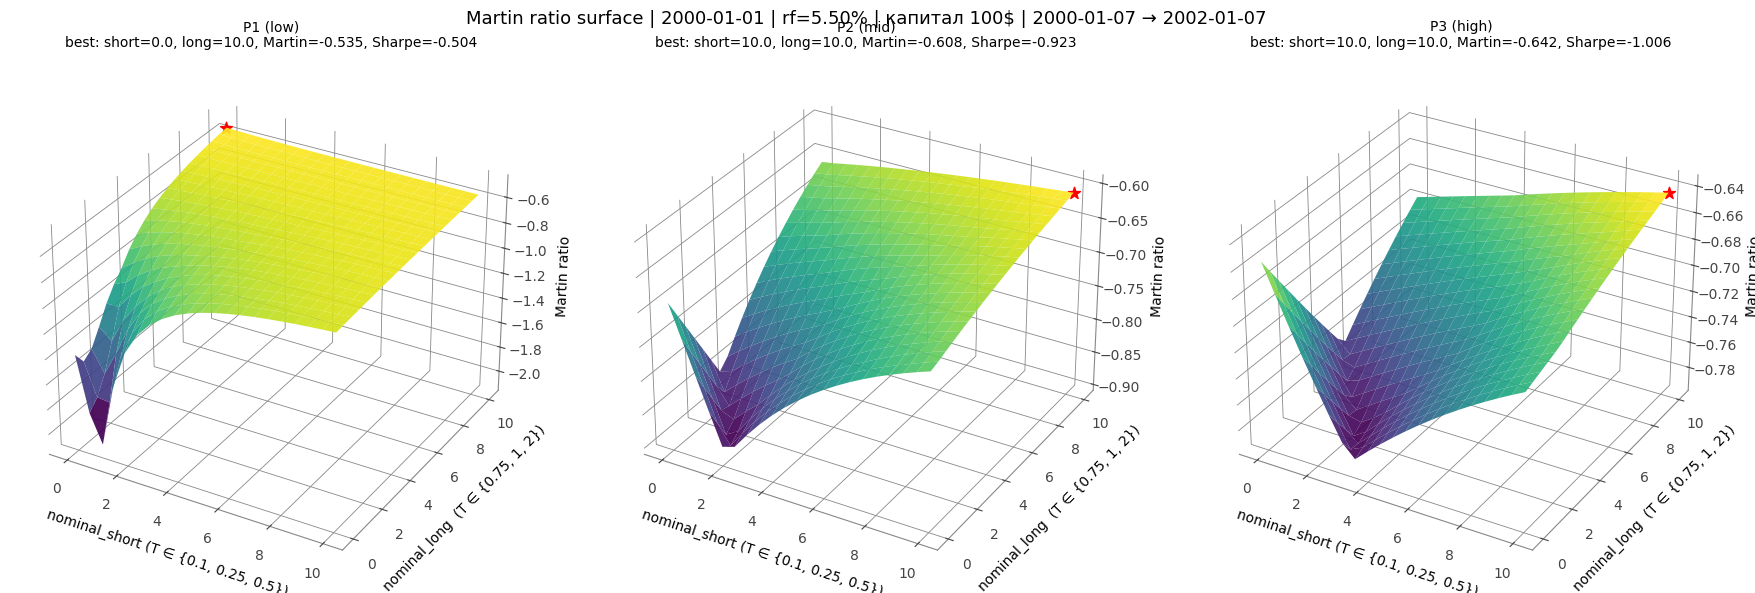

=== 2000-01-01 | rf=5.50% | период 2000-01-07 → 2002-01-07 | метрика: Sharpe ===
  P1 (low): nominal_short* = 0.0, nominal_long* = 10.0, Sharpe* = -0.504, Martin@opt = -0.535
  P2 (mid): nominal_short* = 0.0, nominal_long* = 10.0, Sharpe* = -0.739, Martin@opt = -0.659
  P3 (high): nominal_short* = 0.0, nominal_long* = 0.0, Sharpe* = -0.824, Martin@opt = -0.655


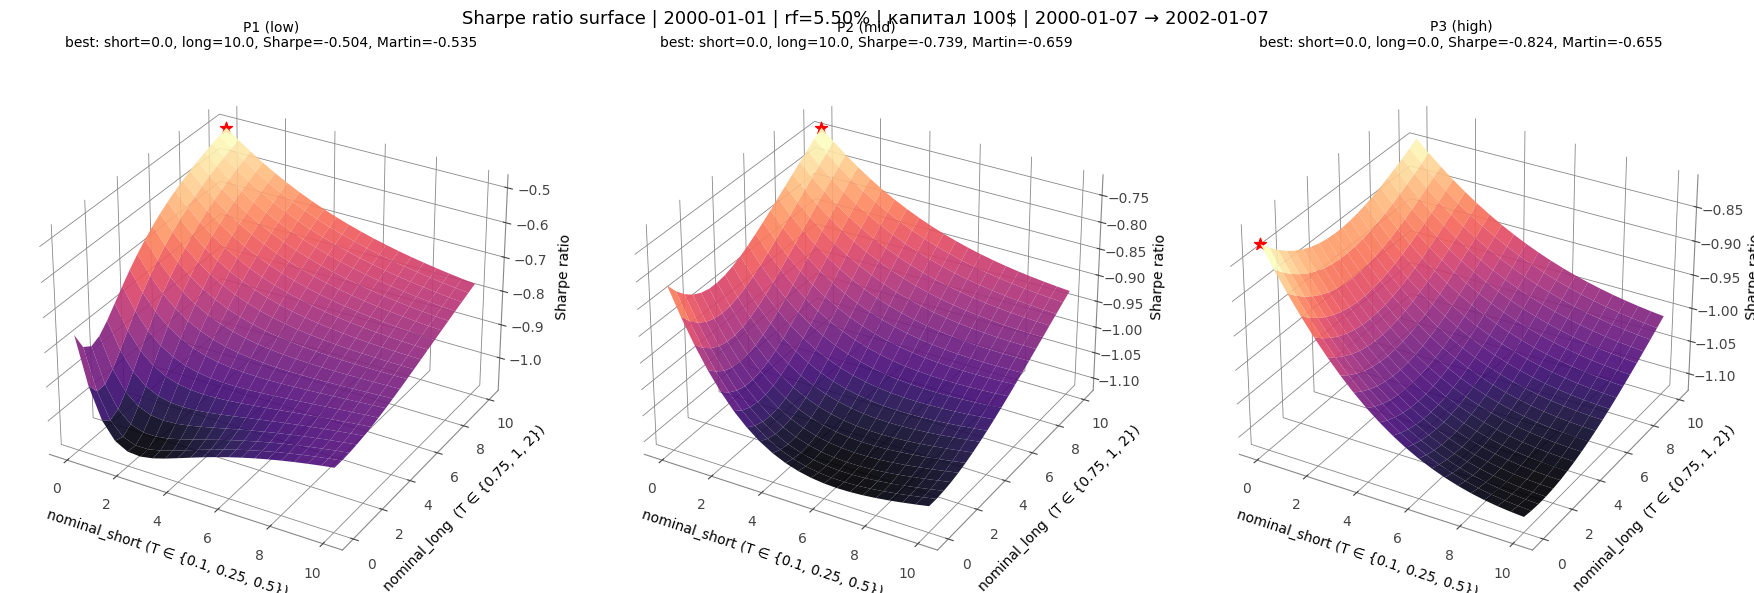

In [15]:
plot_grid_for_portfolios(
    _config, _prices, _swap_pnl_by_T,
    PORTFOLIOS, rf_rate=0.055, label="2000-01-01", metric="martin",
    initial_capital=100.0, years=2, nom_min=0.0, nom_max=10.0, nom_step=0.5,
)
plot_grid_for_portfolios(
    _config, _prices, _swap_pnl_by_T,
    PORTFOLIOS, rf_rate=0.055, label="2000-01-01", metric="sharpe",
    initial_capital=100.0, years=2, nom_min=0.0, nom_max=10.0, nom_step=0.5,
)

=== 2007-01-01 | rf=4.75% | период 2007-01-09 → 2009-01-09 | метрика: Martin ===
  P1 (low): nominal_short* = 10.0, nominal_long* = 10.0, Martin* = +28.474, Sharpe@opt = +2.135
  P2 (mid): nominal_short* = 10.0, nominal_long* = 10.0, Martin* = +14.034, Sharpe@opt = +1.860
  P3 (high): nominal_short* = 10.0, nominal_long* = 10.0, Martin* = +0.307, Sharpe@opt = +0.147


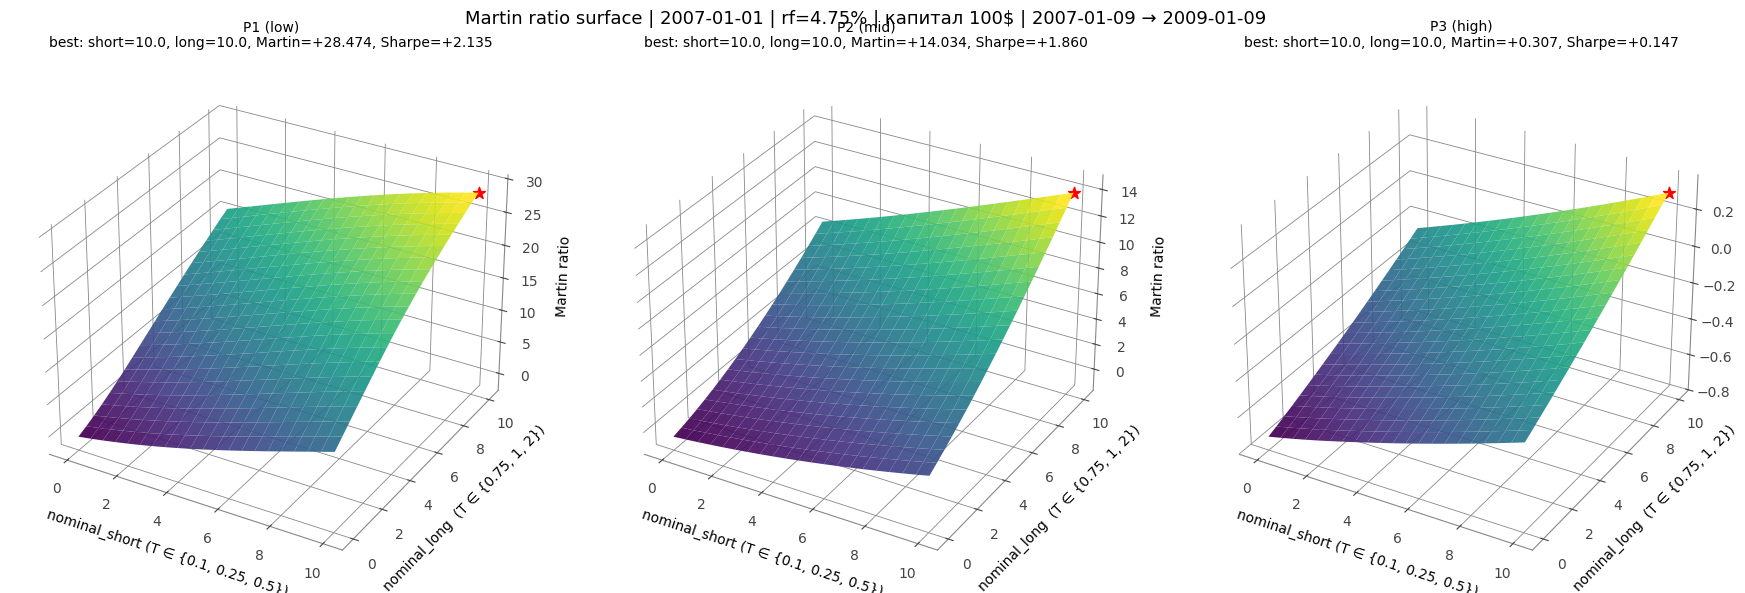

=== 2007-01-01 | rf=4.75% | период 2007-01-09 → 2009-01-09 | метрика: Sharpe ===
  P1 (low): nominal_short* = 0.0, nominal_long* = 10.0, Sharpe* = +2.482, Martin@opt = +15.819
  P2 (mid): nominal_short* = 6.0, nominal_long* = 10.0, Sharpe* = +1.881, Martin@opt = +10.900
  P3 (high): nominal_short* = 10.0, nominal_long* = 10.0, Sharpe* = +0.147, Martin@opt = +0.307


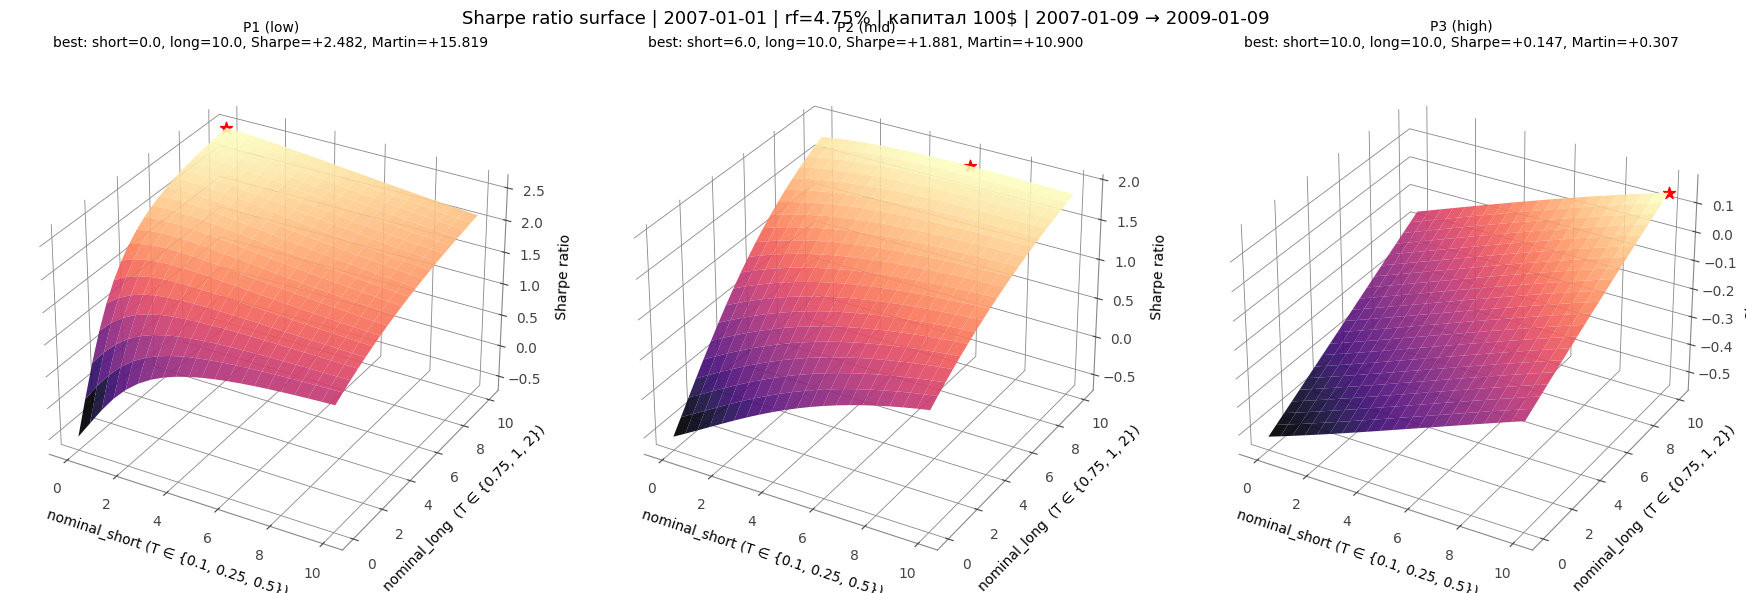

In [16]:
plot_grid_for_portfolios(
    _config_2007, _prices_2007, _swap_pnl_by_T_2007,
    PORTFOLIOS_2007, rf_rate=0.0475, label="2007-01-01", metric="martin",
    initial_capital=100.0, years=2, nom_min=0.0, nom_max=10.0, nom_step=0.5,
)
plot_grid_for_portfolios(
    _config_2007, _prices_2007, _swap_pnl_by_T_2007,
    PORTFOLIOS_2007, rf_rate=0.0475, label="2007-01-01", metric="sharpe",
    initial_capital=100.0, years=2, nom_min=0.0, nom_max=10.0, nom_step=0.5,
)

=== 2019-01-01 | rf=2.40% | период 2019-01-08 → 2021-01-08 | метрика: Martin ===
  P1 (low): nominal_short* = 0.0, nominal_long* = 0.0, Martin* = +9.055, Sharpe@opt = +1.627
  P2 (mid): nominal_short* = 0.0, nominal_long* = 0.5, Martin* = +11.127, Sharpe@opt = +1.612
  P3 (high): nominal_short* = 0.0, nominal_long* = 1.0, Martin* = +17.969, Sharpe@opt = +1.919


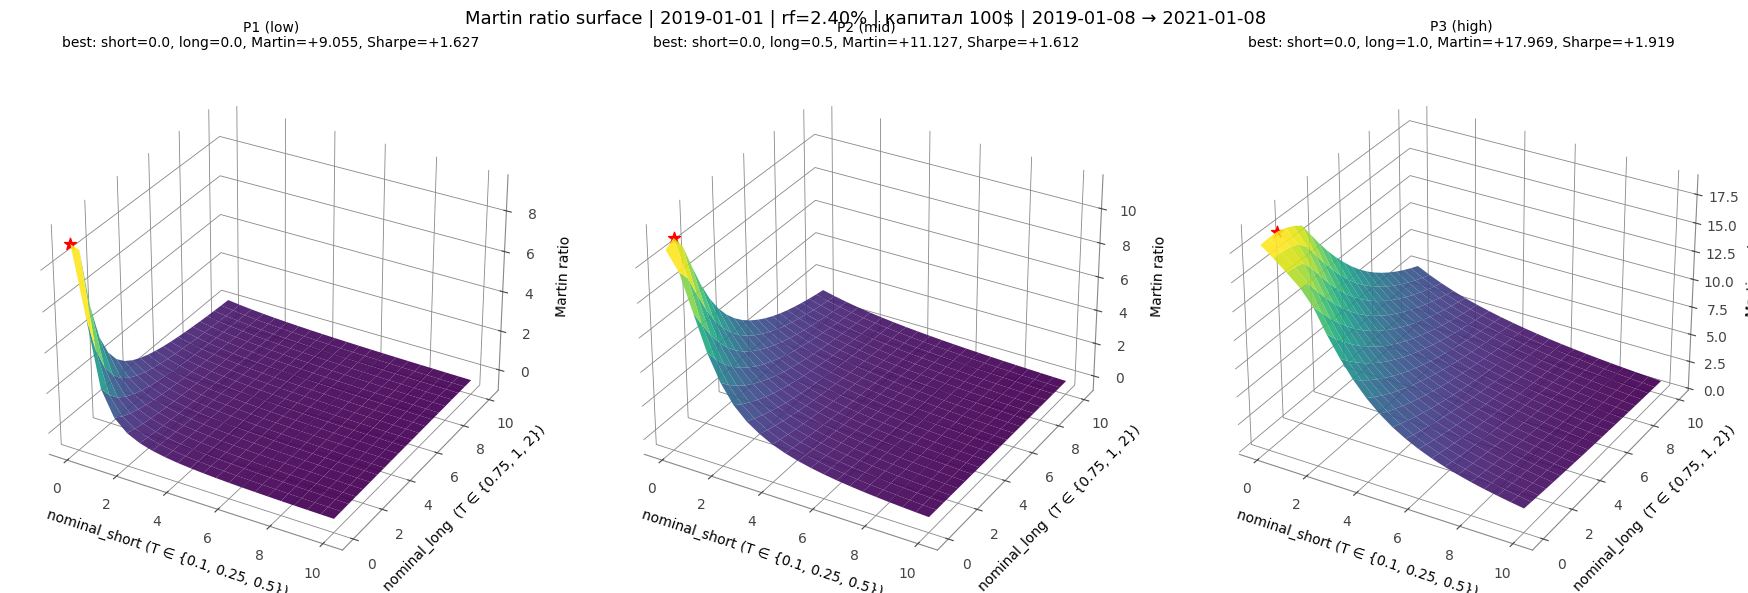

=== 2019-01-01 | rf=2.40% | период 2019-01-08 → 2021-01-08 | метрика: Sharpe ===
  P1 (low): nominal_short* = 0.0, nominal_long* = 0.0, Sharpe* = +1.627, Martin@opt = +9.055
  P2 (mid): nominal_short* = 0.0, nominal_long* = 0.0, Sharpe* = +1.625, Martin@opt = +10.809
  P3 (high): nominal_short* = 0.0, nominal_long* = 0.0, Sharpe* = +1.932, Martin@opt = +17.896


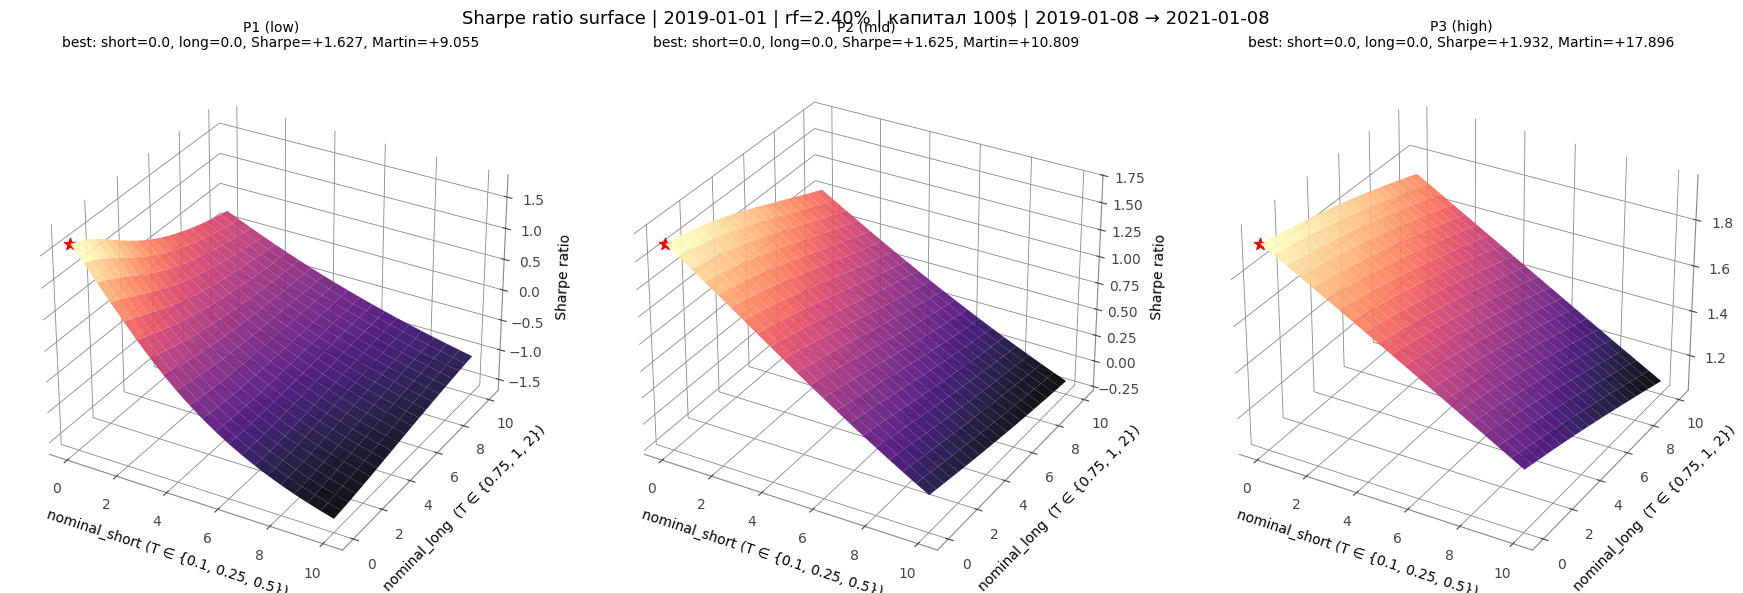

In [17]:
plot_grid_for_portfolios(
    _config_2019, _prices_2019, _swap_pnl_by_T_2019,
    PORTFOLIOS_2019, rf_rate=0.0240, label="2019-01-01", metric="martin",
    initial_capital=100.0, years=2, nom_min=0.0, nom_max=10.0, nom_step=0.5,
)
plot_grid_for_portfolios(
    _config_2019, _prices_2019, _swap_pnl_by_T_2019,
    PORTFOLIOS_2019, rf_rate=0.0240, label="2019-01-01", metric="sharpe",
    initial_capital=100.0, years=2, nom_min=0.0, nom_max=10.0, nom_step=0.5,
)

=== 2000-01-01 | rf=5.50% | период 2000-01-07 → 2002-01-07 | метрика: Martin ===
  P1 (low): nominal_short* = 0.0, nominal_long* = 10.0, Martin* = -0.368, Sharpe@opt = -0.313


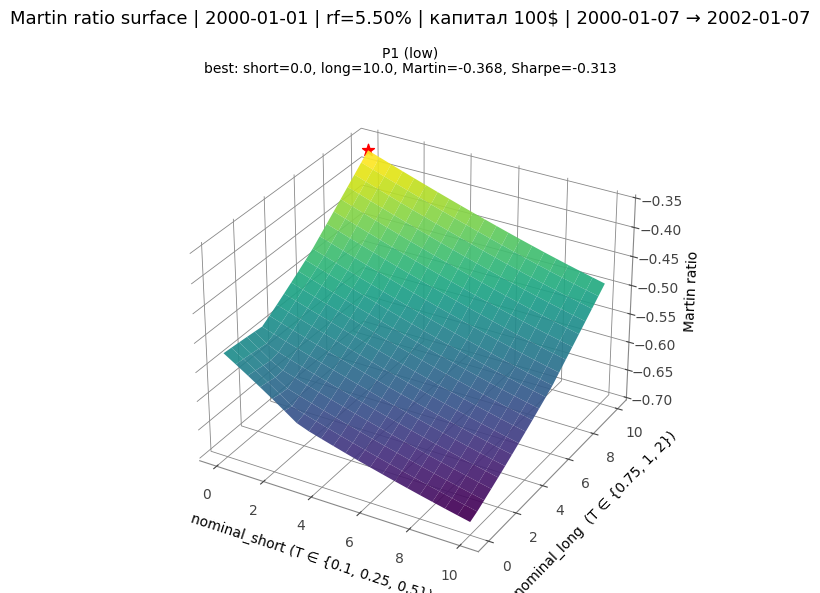

In [18]:
PORTFOLIOS_2000_tech = {
    "P1 (low)": {
        "Intel":     0.1,
        "Oracle":    0.1,
        "Qualcomm":  0.1,
        "Amazon":    0.1,
        "Amazon":    0.1,
        "Cisco":     0.1,
    },
}
plot_martin_grid_for_portfolios(
    _config, _prices, _swap_pnl_by_T,
    PORTFOLIOS_2000_tech, rf_rate=0.055, label="2000-01-01",
    initial_capital=100.0, years=2,
    nom_min=0.0, nom_max=10.0, nom_step=0.5,
)

In [19]:
def load_corr_strategy_data(folder: str | Path):
    """Загружает данные для динамической стратегии торговли корреляционными свопами.

    Возвращает (config, prices, swap_quotes_by_pair, rho_by_pair):
        config              — JSON конфиг (assets, T_array, report_date, …).
        prices              — close-цены с фильтрацией от strategy_start
                              (первая дата, где у всех свопов уже есть котировка).
        swap_quotes_by_pair — dict[(asset1, asset2)] -> DataFrame с колонками
                              [date, T_start, T_cur, value_ff].
                              value_ff = ffill(value) (без bfill — leading NaN
                              нам нужны, чтобы не открывать позицию до warm-up).
        rho_by_pair         — dict[(asset1, asset2)] -> pd.Series rho по датам
                              из rolling_correlations.csv.
    """
    folder = Path(folder)
    with open(folder / "config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    prices = pd.read_csv(folder / "prices_close.csv", parse_dates=["date"]).set_index("date")
    report_date = pd.Timestamp(config["report_date"])
    prices = prices[prices.index >= report_date].sort_index()
    prices = prices[config["assets"]]

    swap_paths = pd.read_csv(folder / "swap_paths.csv", parse_dates=["date", "expiry_date"])
    sp = swap_paths.copy()
    sp = sp.sort_values(["asset1", "asset2", "T_start", "date"])
    sp["value_ff"] = sp.groupby(["asset1", "asset2", "T_start"])["value"].ffill()

    valid = swap_paths.dropna(subset=["value"]).copy()
    first_valid_dates = valid.groupby(["asset1", "asset2", "T_start"])["date"].min()
    strategy_start = pd.Timestamp(first_valid_dates.max())
    prices = prices[prices.index >= strategy_start]

    rolling = pd.read_csv(folder / "rolling_correlations.csv", parse_dates=["date"])
    rho_by_pair: dict[tuple[str, str], pd.Series] = {}
    for (a, b), grp in rolling.groupby(["asset1", "asset2"]):
        rho_by_pair[(a, b)] = grp.set_index("date")["rho"].sort_index()

    swap_quotes_by_pair: dict[tuple[str, str], pd.DataFrame] = {}
    for (a, b), grp in sp.groupby(["asset1", "asset2"]):
        swap_quotes_by_pair[(a, b)] = (
            grp[["date", "T_start", "T_cur", "value_ff"]]
            .sort_values(["T_start", "date"])
            .reset_index(drop=True)
        )

    return config, prices, swap_quotes_by_pair, rho_by_pair

In [20]:
def simulate_dynamic_corr_strategy(
    config, prices, swap_quotes_by_pair, rho_by_pair,
    weights: dict[str, float],
    end_date,
    rf_rate: float = 0.055,
    initial_capital: float = 100.0,
    *,
    win_short: int = 3,
    win_long:  int = 10,
    target_T_days: float = 30.0,
    tolerance_T_days: float = 30.0,
    take_profit: float = 0.20,
    stop_loss:   float = 0.20,
    nominal_scale: float = 10.0,
    min_anchor_abs: float = 0.05,
    eps_signal: float = 1e-3,
):
    """Funded-портфель ($ initial_capital) + динамическая стратегия по парам корреляций.

    Cash + index — как в simulate_funded_portfolio. Свопы — динамические:

    Сигнал по каждой паре (a, b), где обе компоненты входят в портфель (w > 0):
        m3   = средняя ρ_{a,b} за последние win_short точек
        m10  = средняя ρ_{a,b} за последние win_long  точек
        если |m10| > 0.05 и sign(m10) == sign(m3):
            signed = m3 / m10 − 1     (>0 → корр. растёт, <0 → падает)
        иначе (m10 ≈ 0 или знаки разные):
            signed = m3 − m10         (защита от взрыва ratio)
        |signed| ≤ eps_signal — сигнала нет, удерживаем текущую позицию.

    Вход: на сигнал ищется «короткий» своп пары — с T_cur ближе всего к
    target_T_days и в коридоре ±tolerance_T_days; если такого нет — пропуск.
    Направление: long при signed > 0, short при signed < 0.
    Номинал: nominal_scale * |signed|.

    Выход:
      * |unrealized_pnl_pct| ≥ take_profit (+20 %)  → закрываем (TP);
      * unrealized_pnl_pct  ≤ −stop_loss   (−20 %)  → закрываем (SL);
      * своп истёк (T_cur ≤ 0)                     → закрываем по последней цене;
      * end_date                                   → форс-клоуз.
    После закрытия следующая дата уже доступна для входа.

    Защита: если |anchor| < min_anchor_abs, в знаменателе pnl_pct берём
    min_anchor_abs (иначе % взлетает до бесконечности на «нулевых» свопах).

    Возвращает dict: total_pnl/swap_pnl/asset_value/cash + trade_log (DataFrame).
    """
    target_T = target_T_days / 365.0
    tol_T    = tolerance_T_days / 365.0

    active = {a: float(w) for a, w in weights.items() if w > 0 and a in prices.columns}
    if not active:
        return None

    sub = prices[list(active.keys())]
    sub = sub[sub.index <= pd.Timestamp(end_date)].dropna(how="any")
    if len(sub) < 2:
        return None

    dates = sub.index
    p0 = sub.iloc[0]
    norm = sub / p0
    w = pd.Series(active)
    asset_value = (norm * w).sum(axis=1) * initial_capital

    cash_weight = 1.0 - float(w.sum())
    days = (dates - dates[0]).days.values.astype(float)
    dt = np.diff(days, prepend=days[0]) / 365.0
    cash = np.empty(len(dates))
    cash[0] = cash_weight * initial_capital
    for i in range(1, len(dates)):
        cash[i] = cash[i - 1] * (1.0 + rf_rate * dt[i])
    cash = pd.Series(cash, index=dates)

    swap_pnl = pd.Series(0.0, index=dates)
    active_set = set(active.keys())
    trade_log: list[dict] = []

    for (a1, a2), quotes in swap_quotes_by_pair.items():
        if a1 not in active_set or a2 not in active_set:
            continue
        rho = rho_by_pair.get((a1, a2))
        if rho is None:
            continue

        rho_aligned = rho.reindex(dates).ffill()
        m3  = rho_aligned.rolling(win_short, min_periods=win_short).mean()
        m10 = rho_aligned.rolling(win_long,  min_periods=win_long ).mean()

        q = quotes[quotes["date"].isin(dates)]
        v_pivot = q.pivot_table(index="date", columns="T_start", values="value_ff", aggfunc="last")
        T_pivot = q.pivot_table(index="date", columns="T_start", values="T_cur",   aggfunc="last")
        v_pivot = v_pivot.reindex(dates).ffill()
        T_pivot = T_pivot.reindex(dates)
        T_starts = list(v_pivot.columns)

        pos = 0; pos_T = None; pos_anchor = None; pos_units = 0.0
        pair_realized = 0.0
        pair_pnl_d = pd.Series(0.0, index=dates)

        for d in dates:
            unreal = 0.0
            if pos != 0 and pos_T is not None:
                cur_T_cur = T_pivot.at[d, pos_T] if pos_T in T_pivot.columns else np.nan
                cur_val   = v_pivot.at[d, pos_T] if pos_T in v_pivot.columns else np.nan
                expired = pd.isna(cur_T_cur) or cur_T_cur <= 0
                if pd.isna(cur_val):
                    cur_val = pos_anchor
                if expired:
                    realized = pos * pos_units * (cur_val - pos_anchor)
                    pair_realized += realized
                    trade_log.append({
                        "pair": f"{a1}|{a2}", "date": d, "event": "expire",
                        "T": float(pos_T), "anchor": float(pos_anchor),
                        "exit": float(cur_val), "units": float(pos_units),
                        "realized": float(realized), "pos": int(pos),
                    })
                    pos, pos_T, pos_anchor, pos_units = 0, None, None, 0.0
                else:
                    delta_per_unit = pos * (cur_val - pos_anchor)
                    base = max(abs(pos_anchor), min_anchor_abs)
                    pnl_pct = delta_per_unit / base
                    if pnl_pct >= take_profit or pnl_pct <= -stop_loss:
                        unreal_close = pos * pos_units * (cur_val - pos_anchor)
                        pair_realized += unreal_close
                        trade_log.append({
                            "pair": f"{a1}|{a2}", "date": d,
                            "event": "tp" if pnl_pct >= take_profit else "sl",
                            "T": float(pos_T), "anchor": float(pos_anchor),
                            "exit": float(cur_val), "units": float(pos_units),
                            "pnl_pct": float(pnl_pct), "realized": float(unreal_close),
                            "pos": int(pos),
                        })
                        pos, pos_T, pos_anchor, pos_units = 0, None, None, 0.0
                    else:
                        unreal = pos * pos_units * (cur_val - pos_anchor)

            if pos == 0:
                m3v  = m3.get(d, np.nan)
                m10v = m10.get(d, np.nan)
                if not (pd.isna(m3v) or pd.isna(m10v)):
                    if abs(m10v) > 0.05 and np.sign(m10v) == np.sign(m3v) and m10v != 0:
                        signed = (m3v / m10v) - 1.0
                    else:
                        signed = m3v - m10v
                    if abs(signed) > eps_signal:
                        direction = int(np.sign(signed))
                        units = nominal_scale * abs(signed)
                        best_T = None; best_dist = None; best_val = None
                        for T_s in T_starts:
                            T_cur_d = T_pivot.at[d, T_s]
                            v_d = v_pivot.at[d, T_s]
                            if pd.isna(T_cur_d) or T_cur_d <= 0 or pd.isna(v_d):
                                continue
                            dist = abs(T_cur_d - target_T)
                            if dist > tol_T:
                                continue
                            if best_dist is None or dist < best_dist:
                                best_dist, best_T, best_val = dist, T_s, v_d
                        if best_T is not None:
                            pos = direction
                            pos_T = best_T
                            pos_anchor = float(best_val)
                            pos_units  = float(units)
                            trade_log.append({
                                "pair": f"{a1}|{a2}", "date": d,
                                "event": "open_long" if direction > 0 else "open_short",
                                "T": float(best_T), "anchor": float(pos_anchor),
                                "units": float(pos_units),
                                "signed": float(signed), "m3": float(m3v), "m10": float(m10v),
                            })

            pair_pnl_d.loc[d] = pair_realized + unreal

        if pos != 0:
            d_last = dates[-1]
            cur_val = v_pivot.at[d_last, pos_T] if pos_T in v_pivot.columns else pos_anchor
            if pd.isna(cur_val):
                cur_val = pos_anchor
            realized = pos * pos_units * (cur_val - pos_anchor)
            pair_realized += realized
            trade_log.append({
                "pair": f"{a1}|{a2}", "date": d_last, "event": "force_close_eop",
                "T": float(pos_T), "anchor": float(pos_anchor), "exit": float(cur_val),
                "units": float(pos_units), "realized": float(realized), "pos": int(pos),
            })
            pair_pnl_d.loc[d_last] = pair_realized

        swap_pnl = swap_pnl.add(pair_pnl_d, fill_value=0.0)

    total_value = cash + asset_value + swap_pnl
    total_pnl = total_value - initial_capital

    return {
        "dates": dates,
        "cash": cash,
        "asset_value": asset_value,
        "asset_pnl":   asset_value - asset_value.iloc[0],
        "swap_pnl":    swap_pnl,
        "total_value": total_value,
        "total_pnl":   total_pnl,
        "initial_capital": initial_capital,
        "weights": active,
        "cash_weight": cash_weight,
        "trade_log": pd.DataFrame(trade_log),
    }

In [21]:
def run_dynamic_strategy_for_portfolios(
    config, prices, swap_quotes_by_pair, rho_by_pair, portfolios,
    rf_rate: float,
    label: str,
    initial_capital: float = 100.0,
    years: float = 2.0,
    **strategy_kwargs,
):
    """Гоняет динамическую корреляционную стратегию для трёх портфелей,
    рисует total/asset/swap P&L и печатает Sharpe/Martin + статистику трейдов.
    """
    start = prices.index[0]
    end_idx = int(prices.index.searchsorted(start + pd.DateOffset(years=int(years)), side="right")) - 1
    end_idx = min(end_idx, len(prices) - 1)
    end_date = prices.index[end_idx]

    fig, axes = plt.subplots(1, len(portfolios), figsize=(18, 5.5), sharex=True)
    if len(portfolios) == 1:
        axes = [axes]

    print(f"=== Динамическая корреляционная стратегия | {label} | "
          f"rf={rf_rate*100:.2f}% | период {start.date()} → {end_date.date()} | "
          f"капитал {initial_capital:.0f}$ ===")
    print(f"  параметры: win_short={strategy_kwargs.get('win_short', 3)}, "
          f"win_long={strategy_kwargs.get('win_long', 10)}, "
          f"target_T={strategy_kwargs.get('target_T_days', 30):.0f}d ± "
          f"{strategy_kwargs.get('tolerance_T_days', 30):.0f}d, "
          f"TP={strategy_kwargs.get('take_profit', 0.20)*100:.0f}% / "
          f"SL={strategy_kwargs.get('stop_loss', 0.20)*100:.0f}%, "
          f"nominal_scale={strategy_kwargs.get('nominal_scale', 10.0):.1f}")

    summary = []
    for ax, (name, w_dict) in zip(axes, portfolios.items()):
        res = simulate_dynamic_corr_strategy(
            config, prices, swap_quotes_by_pair, rho_by_pair, w_dict,
            end_date=end_date, rf_rate=rf_rate, initial_capital=initial_capital,
            **strategy_kwargs,
        )
        if res is None:
            ax.set_title(f"{name}: нет данных")
            continue

        sh, mt = compute_ratios(res["total_pnl"], res["initial_capital"], rf_rate)
        d = res["dates"]
        ax.plot(d, res["total_pnl"], color="#1f77b4", lw=2.0,  label="Total P&L")
        ax.plot(d, res["asset_pnl"], color="#2ca02c", lw=1.4,  alpha=0.85, label="Asset P&L")
        ax.plot(d, res["swap_pnl"],  color="#d62728", lw=1.4,  alpha=0.85, label="Swap P&L (dyn)")
        ax.axhline(0, color="#888", lw=0.6, alpha=0.6)
        ax.set_title(f"{name}\nSharpe = {sh:+.3f}, Martin = {mt:+.3f}", fontsize=11)
        ax.set_ylabel("P&L, $")
        ax.legend(loc="best", fontsize=8, framealpha=0.0)

        log = res["trade_log"]
        if len(log):
            n_open  = log["event"].str.startswith("open").sum()
            n_tp    = (log["event"] == "tp").sum()
            n_sl    = (log["event"] == "sl").sum()
            n_exp   = (log["event"] == "expire").sum()
            n_force = (log["event"] == "force_close_eop").sum()
            avg_units = log.loc[log["event"].str.startswith("open"), "units"].mean()
        else:
            n_open = n_tp = n_sl = n_exp = n_force = 0
            avg_units = float("nan")

        summary.append({
            "portfolio": name,
            "total_pnl_end": res["total_pnl"].iloc[-1],
            "asset_pnl_end": res["asset_pnl"].iloc[-1],
            "swap_pnl_end":  res["swap_pnl"].iloc[-1],
            "sharpe": sh, "martin": mt,
            "open": int(n_open), "tp": int(n_tp), "sl": int(n_sl),
            "expire": int(n_exp), "force": int(n_force),
            "avg_units": avg_units,
        })

    fig.suptitle(f"Dynamic correlation-swap strategy | {label} | rf={rf_rate*100:.2f}% | "
                 f"{start.date()} → {end_date.date()}", fontsize=13)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    if summary:
        df = pd.DataFrame(summary).set_index("portfolio")
        for col in ("total_pnl_end", "asset_pnl_end", "swap_pnl_end"):
            df[col] = df[col].map(lambda v: f"{v:+8.2f}$")
        for col in ("sharpe", "martin"):
            df[col] = df[col].map(lambda v: f"{v:+.3f}" if pd.notna(v) else "—")
        df["avg_units"] = df["avg_units"].map(lambda v: f"{v:.3f}" if pd.notna(v) else "—")
        print()
        print(df.to_string())
    return summary

=== Динамическая корреляционная стратегия | 2000-01-01 | rf=5.50% | период 2000-01-07 → 2002-01-07 | капитал 100$ ===
  параметры: win_short=3, win_long=10, target_T=30d ± 30d, TP=20% / SL=20%, nominal_scale=10.0


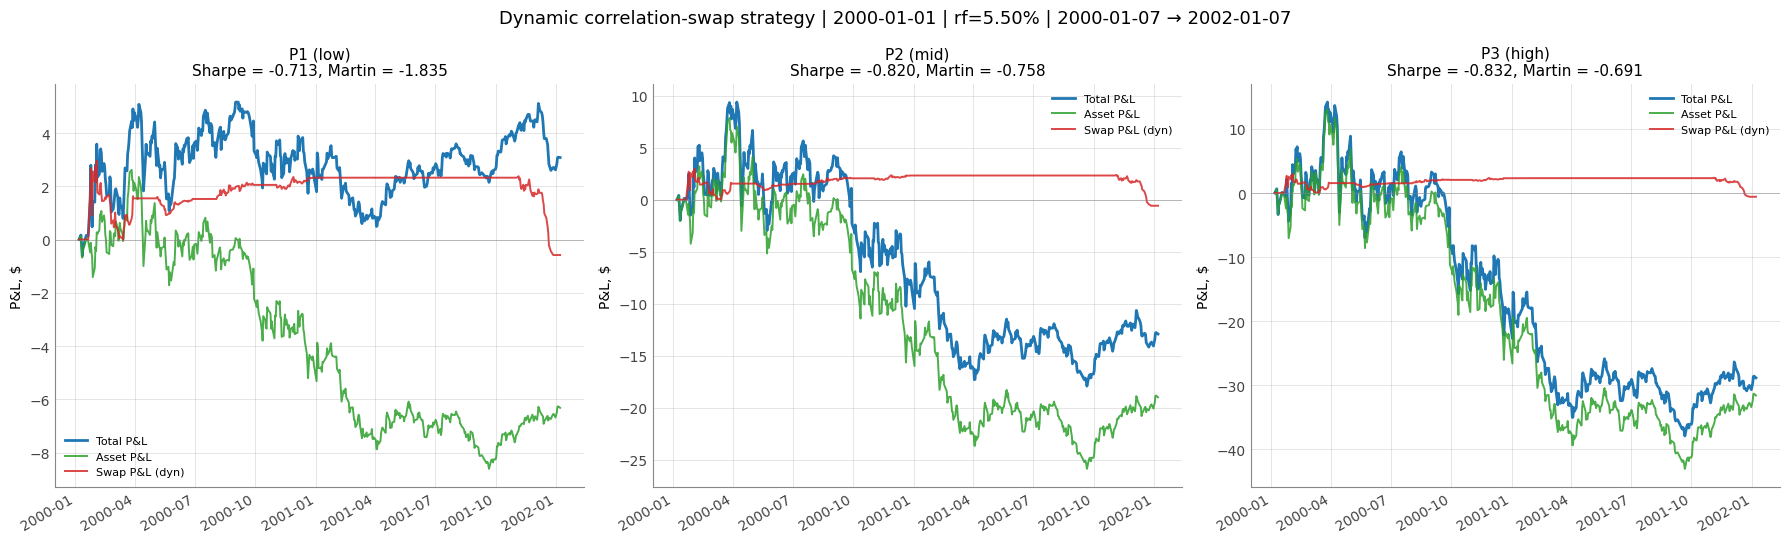


          total_pnl_end asset_pnl_end swap_pnl_end  sharpe  martin  open  tp  sl  expire  force avg_units
portfolio                                                                                                
P1 (low)         +3.08$        -6.32$       -0.58$  -0.713  -1.835   238  63  51     124      0     2.712
P2 (mid)        -12.91$       -18.98$       -0.58$  -0.820  -0.758   238  63  51     124      0     2.712
P3 (high)       -28.87$       -31.63$       -0.58$  -0.832  -0.691   238  63  51     124      0     2.712


In [22]:
_cfg_d, _prices_d, _swap_quotes_d, _rho_d = load_corr_strategy_data("../ml output/2000-01-01")
_ = run_dynamic_strategy_for_portfolios(
    _cfg_d, _prices_d, _swap_quotes_d, _rho_d,
    PORTFOLIOS, rf_rate=0.055, label="2000-01-01",
    initial_capital=100.0, years=2,
    win_short=3, win_long=10,
    target_T_days=30.0, tolerance_T_days=30.0,
    take_profit=0.20, stop_loss=0.20,
    nominal_scale=10.0,
)

=== Динамическая корреляционная стратегия | 2007-01-01 | rf=4.75% | период 2007-01-09 → 2009-01-09 | капитал 100$ ===
  параметры: win_short=3, win_long=10, target_T=30d ± 30d, TP=20% / SL=20%, nominal_scale=10.0


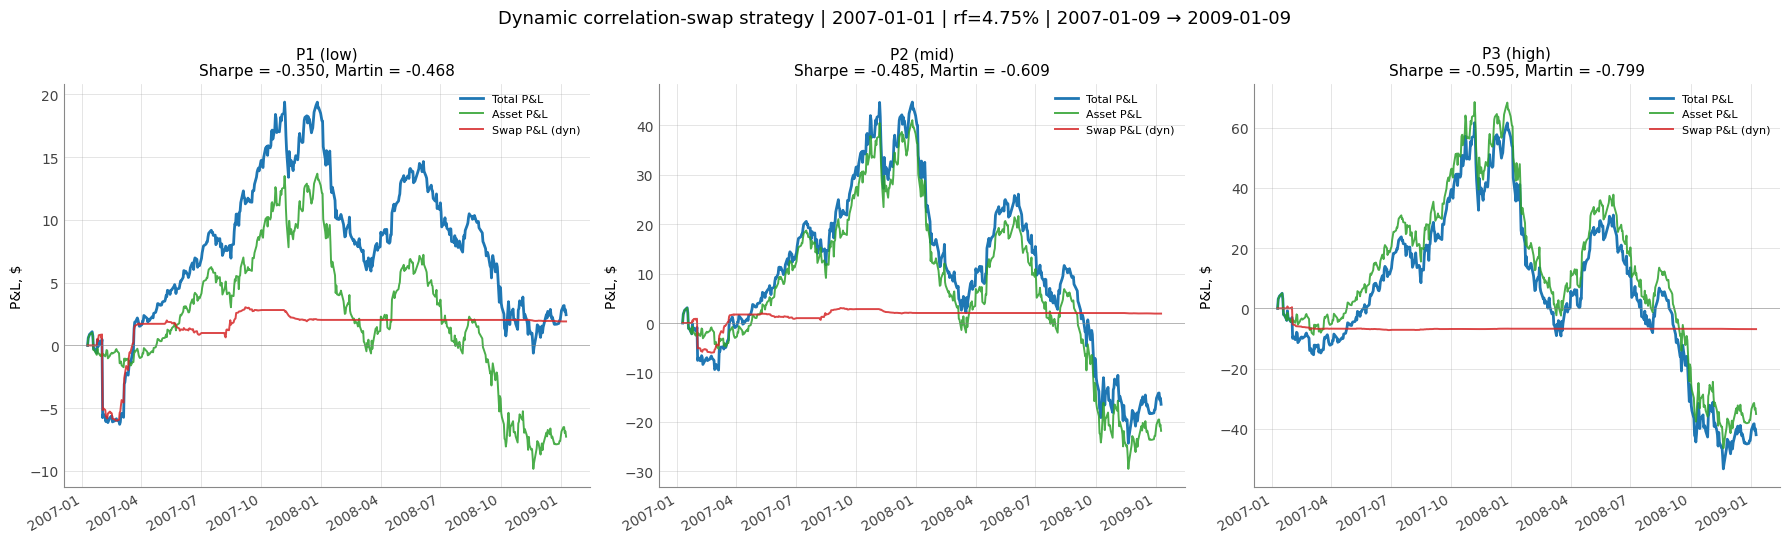


          total_pnl_end asset_pnl_end swap_pnl_end  sharpe  martin  open   tp  sl  expire  force avg_units
portfolio                                                                                                 
P1 (low)         +2.44$        -7.27$       +1.91$  -0.350  -0.468   307  110  77     120      0     2.950
P2 (mid)        -16.44$       -21.82$       +1.91$  -0.485  -0.609   307  110  77     120      0     2.950
P3 (high)       -41.95$       -35.06$       -6.89$  -0.595  -0.799    66   12  19      35      0     2.548


In [23]:
_cfg_d_2007, _prices_d_2007, _swap_quotes_d_2007, _rho_d_2007 = load_corr_strategy_data("../ml output/2007-01-01")
_ = run_dynamic_strategy_for_portfolios(
    _cfg_d_2007, _prices_d_2007, _swap_quotes_d_2007, _rho_d_2007,
    PORTFOLIOS_2007, rf_rate=0.0475, label="2007-01-01",
    initial_capital=100.0, years=2,
    win_short=3, win_long=10,
    target_T_days=30.0, tolerance_T_days=30.0,
    take_profit=0.20, stop_loss=0.20,
    nominal_scale=10.0,
)

=== Динамическая корреляционная стратегия | 2019-01-01 | rf=2.40% | период 2019-01-08 → 2021-01-08 | капитал 100$ ===
  параметры: win_short=3, win_long=10, target_T=30d ± 30d, TP=20% / SL=20%, nominal_scale=10.0


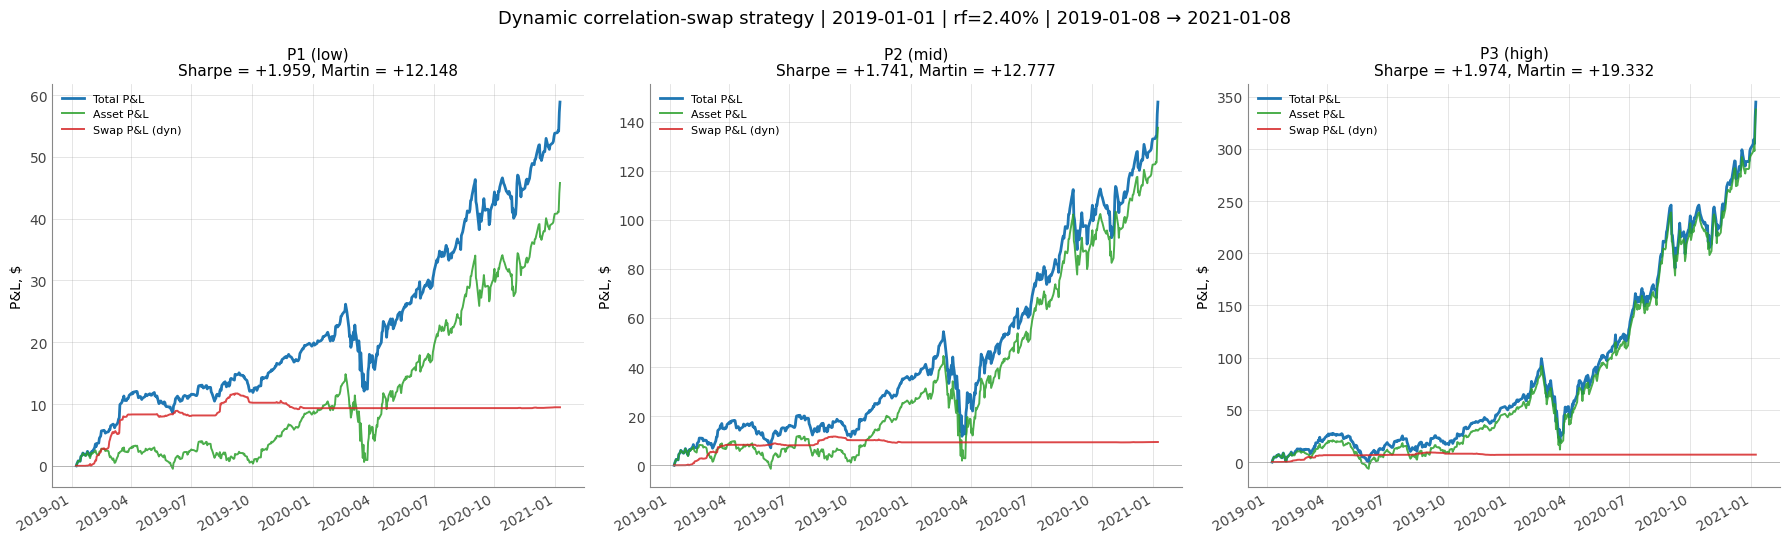


          total_pnl_end asset_pnl_end swap_pnl_end  sharpe   martin  open  tp  sl  expire  force avg_units
portfolio                                                                                                 
P1 (low)        +58.86$       +45.77$       +9.48$  +1.959  +12.148   223  65  34     124      0     3.017
P2 (mid)       +147.93$      +137.46$       +9.48$  +1.741  +12.777   223  65  34     124      0     3.017
P3 (high)      +344.81$      +337.70$       +7.11$  +1.974  +19.332   167  54  25      88      0     3.019


In [24]:
_cfg_d_2019, _prices_d_2019, _swap_quotes_d_2019, _rho_d_2019 = load_corr_strategy_data("../ml output/2019-01-01")
_ = run_dynamic_strategy_for_portfolios(
    _cfg_d_2019, _prices_d_2019, _swap_quotes_d_2019, _rho_d_2019,
    PORTFOLIOS_2019, rf_rate=0.0240, label="2019-01-01",
    initial_capital=100.0, years=2,
    win_short=3, win_long=10,
    target_T_days=30.0, tolerance_T_days=30.0,
    take_profit=0.20, stop_loss=0.20,
    nominal_scale=10.0,
)